# Task 2 - Model Building and Training
### Fraud Detection | 10 Academy KAIM9 | Eleni Melkie

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve, f1_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

sns.set_theme(style="whitegrid")
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [7]:
# Load Fraud_Data splits
X_fraud_train = np.load('../data/processed/X_fraud_train.npy', allow_pickle=True)
y_fraud_train = np.load('../data/processed/y_fraud_train.npy', allow_pickle=True)
X_fraud_test  = np.load('../data/processed/X_fraud_test.npy',  allow_pickle=True)
y_fraud_test  = np.load('../data/processed/y_fraud_test.npy',  allow_pickle=True)

# Load Creditcard splits
X_cc_train = np.load('../data/processed/X_cc_train.npy', allow_pickle=True)
y_cc_train = np.load('../data/processed/y_cc_train.npy', allow_pickle=True)
X_cc_test  = np.load('../data/processed/X_cc_test.npy',  allow_pickle=True)
y_cc_test  = np.load('../data/processed/y_cc_test.npy',  allow_pickle=True)

print("=== Fraud_Data ===")
print("Train:", X_fraud_train.shape, "| Test:", X_fraud_test.shape)
print("Train fraud %:", round(y_fraud_train.mean()*100, 2))
print("Test fraud %: ", round(y_fraud_test.mean()*100, 2))

print("\n=== Creditcard ===")
print("Train:", X_cc_train.shape, "| Test:", X_cc_test.shape)
print("Train fraud %:", round(y_cc_train.mean()*100, 2))
print("Test fraud %: ", round(y_cc_test.mean()*100, 2))
print("✅ Data loaded!")

=== Fraud_Data ===
Train: (187004, 13) | Test: (25830, 13)
Train fraud %: 50.0
Test fraud %:  9.5

=== Creditcard ===
Train: (453204, 30) | Test: (56746, 30)
Train fraud %: 50.0
Test fraud %:  0.17
✅ Data loaded!


In [8]:
def evaluate_model(model, X_test, y_test, model_name, dataset_name):
    """Full evaluation of a trained model"""
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    f1       = f1_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_pred_prob)
    avg_prec = average_precision_score(y_test, y_pred_prob)
    cm       = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name} — {dataset_name}")
    print(f"{'='*55}")
    print(f"  F1-Score:          {f1:.4f}")
    print(f"  ROC-AUC:           {roc_auc:.4f}")
    print(f"  AUC-PR:            {avg_prec:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Legit', 'Fraud']))

    return {
        'model_name':  model_name,
        'dataset':     dataset_name,
        'f1':          round(f1, 4),
        'roc_auc':     round(roc_auc, 4),
        'auc_pr':      round(avg_prec, 4),
        'confusion_matrix': cm,
        'y_pred_prob': y_pred_prob,
        'y_pred':      y_pred
    }

print("✅ Evaluation function ready!")

✅ Evaluation function ready!


In [9]:
def plot_confusion_matrix(cm, model_name, dataset_name, ax):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Legit', 'Fraud'],
        yticklabels=['Legit', 'Fraud'],
        ax=ax
    )
    ax.set_title(f'{model_name}\n{dataset_name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

print("✅ Plot function ready!")

✅ Plot function ready!


In [10]:
def plot_pr_curve(results_list, dataset_name, y_test, ax):
    for result in results_list:
        precision, recall, _ = precision_recall_curve(
            y_test, result['y_pred_prob']
        )
        ax.plot(recall, precision,
                label=f"{result['model_name']} (AUC-PR={result['auc_pr']})")

    ax.set_title(f'Precision-Recall Curve\n{dataset_name}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=8)
    ax.grid(True)

print("✅ PR curve function ready!")

✅ PR curve function ready!


In [11]:
print("Training Logistic Regression on Fraud_Data...")

lr_fraud = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_fraud.fit(X_fraud_train, y_fraud_train)

lr_fraud_results = evaluate_model(
    lr_fraud, X_fraud_test, y_fraud_test,
    "Logistic Regression", "Fraud_Data"
)
print("✅ Done!")

Training Logistic Regression on Fraud_Data...

  Logistic Regression — Fraud_Data
  F1-Score:          0.2801
  ROC-AUC:           0.7585
  AUC-PR:            0.4133

  Classification Report:
              precision    recall  f1-score   support

       Legit       0.95      0.65      0.77     23376
       Fraud       0.17      0.71      0.28      2454

    accuracy                           0.66     25830
   macro avg       0.56      0.68      0.53     25830
weighted avg       0.88      0.66      0.73     25830

✅ Done!


In [12]:
print("Training Random Forest on Fraud_Data...")
print("(This may take 1-2 minutes...)")

rf_fraud = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_fraud.fit(X_fraud_train, y_fraud_train)

rf_fraud_results = evaluate_model(
    rf_fraud, X_fraud_test, y_fraud_test,
    "Random Forest", "Fraud_Data"
)
print("✅ Done!")

Training Random Forest on Fraud_Data...
(This may take 1-2 minutes...)

  Random Forest — Fraud_Data
  F1-Score:          0.7061
  ROC-AUC:           0.7743
  AUC-PR:            0.6380

  Classification Report:
              precision    recall  f1-score   support

       Legit       0.95      1.00      0.98     23376
       Fraud       0.99      0.55      0.71      2454

    accuracy                           0.96     25830
   macro avg       0.97      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830

✅ Done!


In [13]:
print("Training XGBoost on Fraud_Data...")

# Calculate scale_pos_weight for imbalance
neg = (y_fraud_test == 0).sum()
pos = (y_fraud_test == 1).sum()
scale = round(neg / pos, 2)
print(f"scale_pos_weight: {scale}")

xgb_fraud = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_fraud.fit(X_fraud_train, y_fraud_train)

xgb_fraud_results = evaluate_model(
    xgb_fraud, X_fraud_test, y_fraud_test,
    "XGBoost", "Fraud_Data"
)
print("✅ Done!")

Training XGBoost on Fraud_Data...
scale_pos_weight: 9.53

  XGBoost — Fraud_Data
  F1-Score:          0.1852
  ROC-AUC:           0.7717
  AUC-PR:            0.6228

  Classification Report:
              precision    recall  f1-score   support

       Legit       0.95      0.16      0.27     23376
       Fraud       0.10      0.92      0.19      2454

    accuracy                           0.23     25830
   macro avg       0.53      0.54      0.23     25830
weighted avg       0.87      0.23      0.26     25830

✅ Done!


In [14]:
print("Training LightGBM on Fraud_Data...")

lgbm_fraud = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    verbosity=-1
)
lgbm_fraud.fit(X_fraud_train, y_fraud_train)

lgbm_fraud_results = evaluate_model(
    lgbm_fraud, X_fraud_test, y_fraud_test,
    "LightGBM", "Fraud_Data"
)
print("✅ Done!")

Training LightGBM on Fraud_Data...

  LightGBM — Fraud_Data
  F1-Score:          0.7076
  ROC-AUC:           0.7693
  AUC-PR:            0.6369

  Classification Report:
              precision    recall  f1-score   support

       Legit       0.95      1.00      0.98     23376
       Fraud       1.00      0.55      0.71      2454

    accuracy                           0.96     25830
   macro avg       0.98      0.77      0.84     25830
weighted avg       0.96      0.96      0.95     25830

✅ Done!


In [15]:
fraud_results = [
    lr_fraud_results,
    rf_fraud_results,
    xgb_fraud_results,
    lgbm_fraud_results
]

# Comparison table
print("=== FRAUD_DATA MODEL COMPARISON ===")
comparison_fraud = pd.DataFrame([{
    'Model':   r['model_name'],
    'F1':      r['f1'],
    'ROC-AUC': r['roc_auc'],
    'AUC-PR':  r['auc_pr']
} for r in fraud_results])

comparison_fraud = comparison_fraud.sort_values('AUC-PR', ascending=False)
print(comparison_fraud.to_string(index=False))

=== FRAUD_DATA MODEL COMPARISON ===
              Model     F1  ROC-AUC  AUC-PR
      Random Forest 0.7061   0.7743  0.6380
           LightGBM 0.7076   0.7693  0.6369
            XGBoost 0.1852   0.7717  0.6228
Logistic Regression 0.2801   0.7585  0.4133


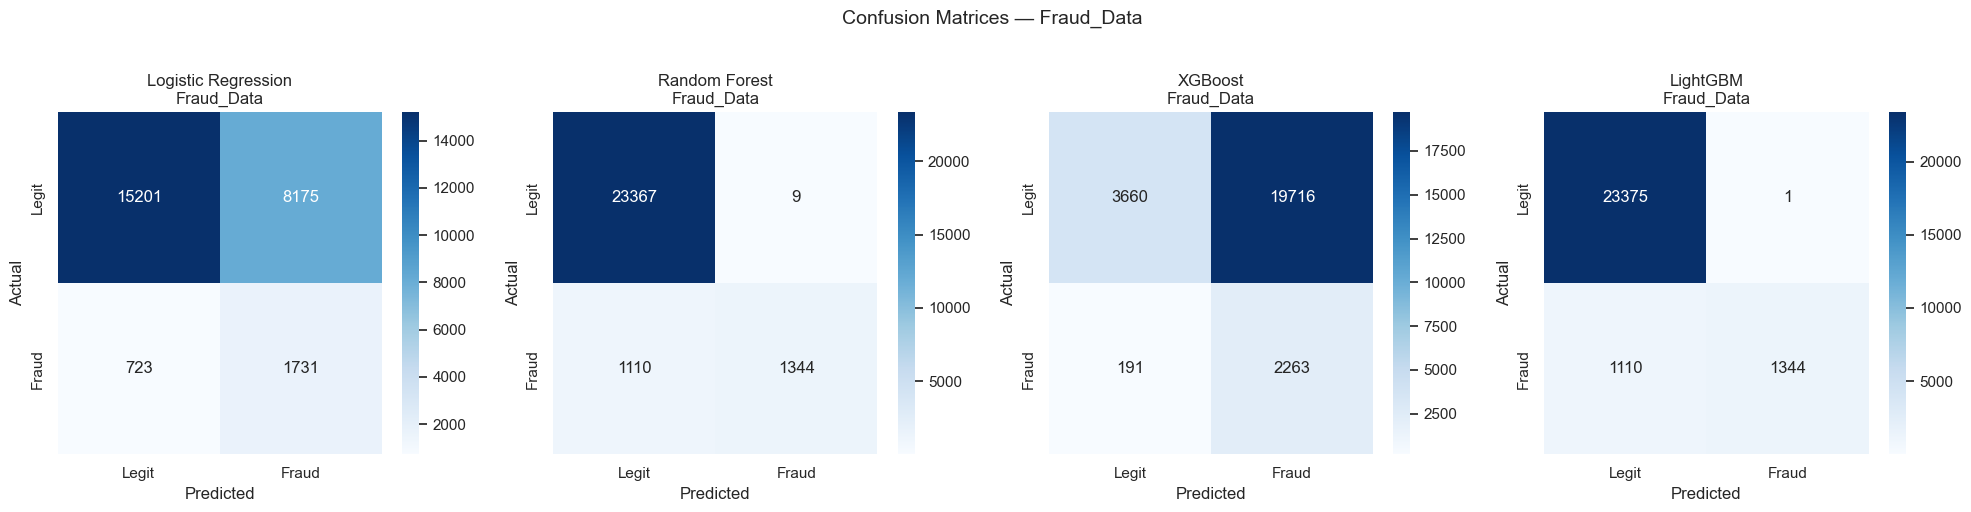

✅ Saved!


In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, result in enumerate(fraud_results):
    plot_confusion_matrix(
        result['confusion_matrix'],
        result['model_name'],
        "Fraud_Data",
        axes[i]
    )

plt.suptitle('Confusion Matrices — Fraud_Data', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

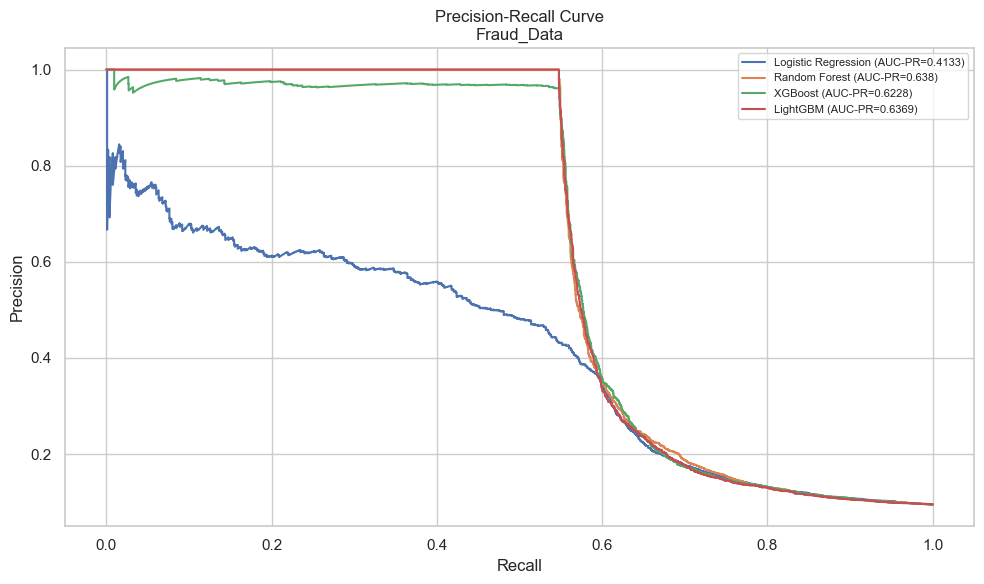

✅ Saved!


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pr_curve(fraud_results, "Fraud_Data", y_fraud_test, ax)
plt.tight_layout()
plt.savefig('../data/processed/pr_curve_fraud.png', dpi=150)
plt.show()
print("✅ Saved!")

In [18]:
print("Training Logistic Regression on Creditcard...")

lr_cc = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
lr_cc.fit(X_cc_train, y_cc_train)

lr_cc_results = evaluate_model(
    lr_cc, X_cc_test, y_cc_test,
    "Logistic Regression", "Creditcard"
)
print("✅ Done!")

Training Logistic Regression on Creditcard...

  Logistic Regression — Creditcard
  F1-Score:          0.1002
  ROC-AUC:           0.9619
  AUC-PR:            0.6768

  Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56651
       Fraud       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

✅ Done!


In [19]:
print("Training Random Forest on Creditcard...")
print("(This may take 2-3 minutes...)")

rf_cc = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_cc.fit(X_cc_train, y_cc_train)

rf_cc_results = evaluate_model(
    rf_cc, X_cc_test, y_cc_test,
    "Random Forest", "Creditcard"
)
print("✅ Done!")

Training Random Forest on Creditcard...
(This may take 2-3 minutes...)

  Random Forest — Creditcard
  F1-Score:          0.6553
  ROC-AUC:           0.9771
  AUC-PR:            0.7797

  Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.55      0.81      0.66        95

    accuracy                           1.00     56746
   macro avg       0.77      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746

✅ Done!


In [20]:
print("Training XGBoost on Creditcard...")

neg_cc = (y_cc_test == 0).sum()
pos_cc = (y_cc_test == 1).sum()
scale_cc = round(neg_cc / pos_cc, 2)
print(f"scale_pos_weight: {scale_cc}")

xgb_cc = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_cc,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_cc.fit(X_cc_train, y_cc_train)

xgb_cc_results = evaluate_model(
    xgb_cc, X_cc_test, y_cc_test,
    "XGBoost", "Creditcard"
)
print("✅ Done!")

Training XGBoost on Creditcard...
scale_pos_weight: 596.33

  XGBoost — Creditcard
  F1-Score:          0.1065
  ROC-AUC:           0.9587
  AUC-PR:            0.7420

  Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56651
       Fraud       0.06      0.86      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

✅ Done!


In [21]:
print("Training LightGBM on Creditcard...")

lgbm_cc = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    class_weight='balanced',
    verbosity=-1
)
lgbm_cc.fit(X_cc_train, y_cc_train)

lgbm_cc_results = evaluate_model(
    lgbm_cc, X_cc_test, y_cc_test,
    "LightGBM", "Creditcard"
)
print("✅ Done!")

Training LightGBM on Creditcard...

  LightGBM — Creditcard
  F1-Score:          0.5253
  ROC-AUC:           0.9705
  AUC-PR:            0.7225

  Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56651
       Fraud       0.39      0.82      0.53        95

    accuracy                           1.00     56746
   macro avg       0.69      0.91      0.76     56746
weighted avg       1.00      1.00      1.00     56746

✅ Done!


In [22]:
cc_results = [
    lr_cc_results,
    rf_cc_results,
    xgb_cc_results,
    lgbm_cc_results
]

print("=== CREDITCARD MODEL COMPARISON ===")
comparison_cc = pd.DataFrame([{
    'Model':   r['model_name'],
    'F1':      r['f1'],
    'ROC-AUC': r['roc_auc'],
    'AUC-PR':  r['auc_pr']
} for r in cc_results])

comparison_cc = comparison_cc.sort_values('AUC-PR', ascending=False)
print(comparison_cc.to_string(index=False))

=== CREDITCARD MODEL COMPARISON ===
              Model     F1  ROC-AUC  AUC-PR
      Random Forest 0.6553   0.9771  0.7797
            XGBoost 0.1065   0.9587  0.7420
           LightGBM 0.5253   0.9705  0.7225
Logistic Regression 0.1002   0.9619  0.6768


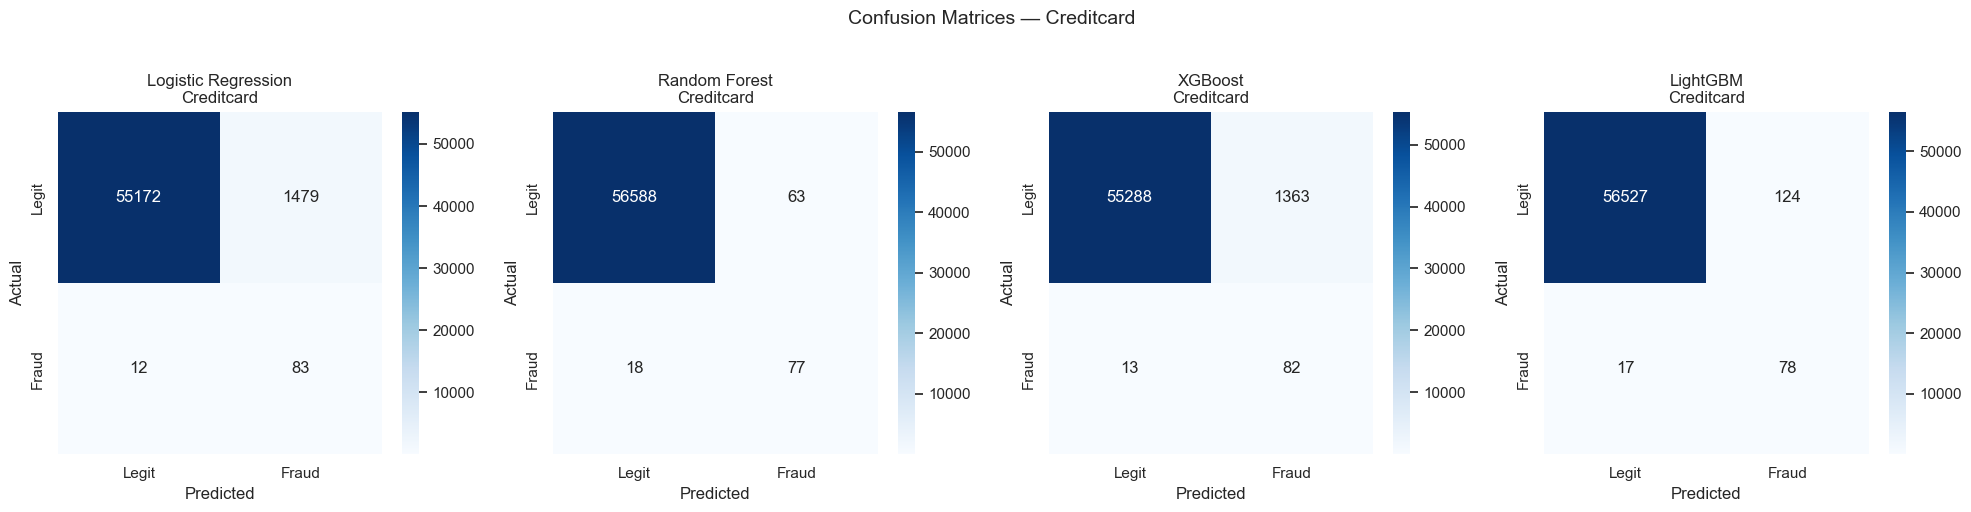

✅ Saved!


In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, result in enumerate(cc_results):
    plot_confusion_matrix(
        result['confusion_matrix'],
        result['model_name'],
        "Creditcard",
        axes[i]
    )

plt.suptitle('Confusion Matrices — Creditcard', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/confusion_matrices_cc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

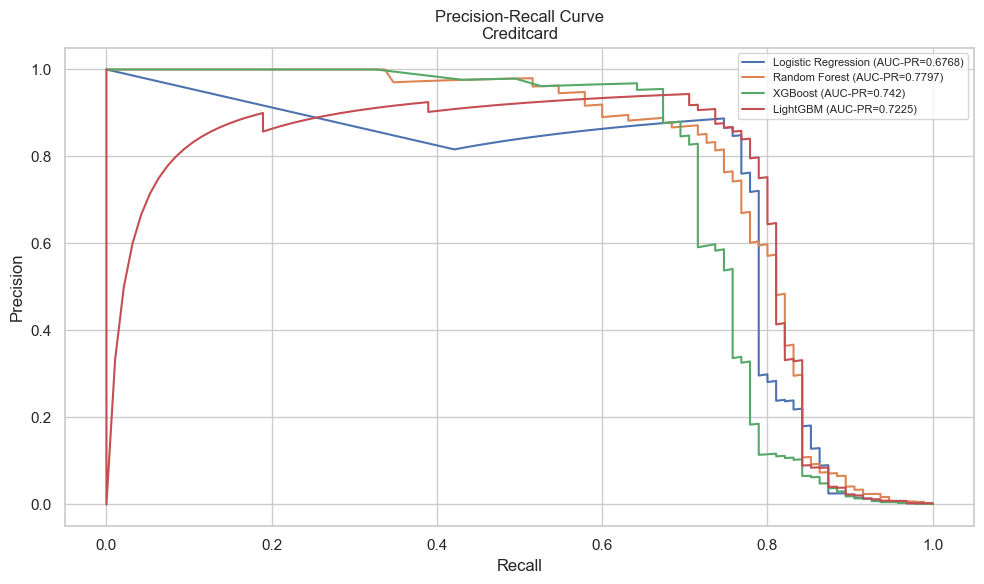

✅ Saved!


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_pr_curve(cc_results, "Creditcard", y_cc_test, ax)
plt.tight_layout()
plt.savefig('../data/processed/pr_curve_cc.png', dpi=150)
plt.show()
print("✅ Saved!")

In [26]:
print("Running 5-Fold Cross Validation...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, class_weight='balanced', verbosity=-1
    )
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(
        model, X_fraud_train, y_fraud_train,
        cv=skf, scoring='f1', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:25s} F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

print("\n✅ Cross validation complete!")

Running 5-Fold Cross Validation...
Logistic Regression       F1: 0.6880 (+/- 0.0011)
Random Forest             F1: 0.7733 (+/- 0.0066)
XGBoost                   F1: 0.9161 (+/- 0.0057)
LightGBM                  F1: 0.9219 (+/- 0.0063)

✅ Cross validation complete!


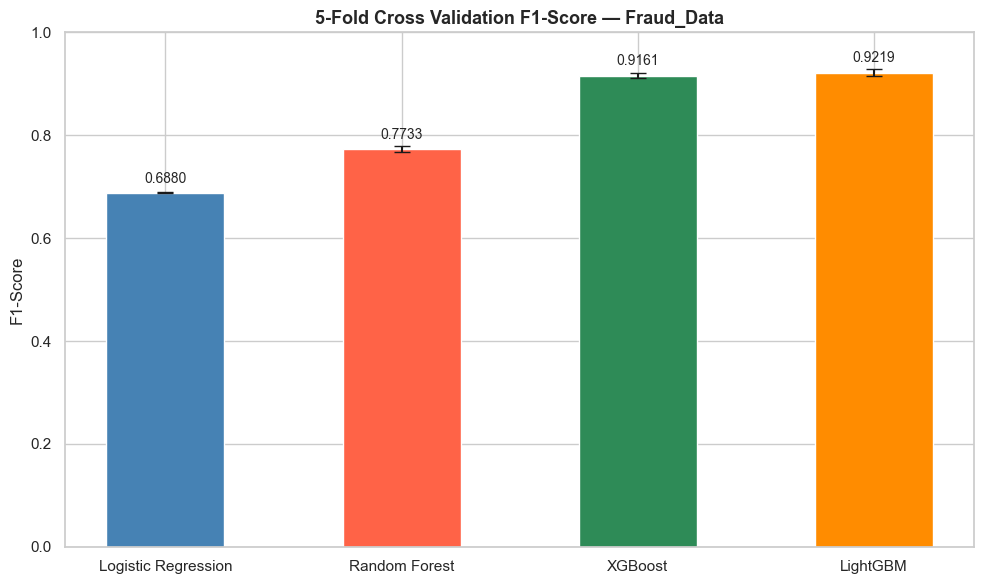

✅ Saved!


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

names  = list(cv_results.keys())
means  = [cv_results[n].mean() for n in names]
stds   = [cv_results[n].std()  for n in names]
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

bars = ax.bar(names, means, yerr=stds, color=colors,
              capsize=6, edgecolor='white', width=0.5)

ax.set_title('5-Fold Cross Validation F1-Score — Fraud_Data',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{mean:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/cv_results.png', dpi=150)
plt.show()
print("✅ Saved!")

In [28]:
# Pick best model per dataset based on AUC-PR
print("=== FINAL MODEL SELECTION ===\n")

# Fraud_Data — find best
best_fraud = max(fraud_results, key=lambda x: x['auc_pr'])
print(f"Best model (Fraud_Data):  {best_fraud['model_name']}")
print(f"  AUC-PR: {best_fraud['auc_pr']} | F1: {best_fraud['f1']}")

# Creditcard — find best
best_cc = max(cc_results, key=lambda x: x['auc_pr'])
print(f"\nBest model (Creditcard):  {best_cc['model_name']}")
print(f"  AUC-PR: {best_cc['auc_pr']} | F1: {best_cc['f1']}")

# Map model names to trained objects
model_map_fraud = {
    'Logistic Regression': lr_fraud,
    'Random Forest':       rf_fraud,
    'XGBoost':             xgb_fraud,
    'LightGBM':            lgbm_fraud
}
model_map_cc = {
    'Logistic Regression': lr_cc,
    'Random Forest':       rf_cc,
    'XGBoost':             xgb_cc,
    'LightGBM':            lgbm_cc
}

# Save best models
os.makedirs('../models', exist_ok=True)

best_fraud_model = model_map_fraud[best_fraud['model_name']]
best_cc_model    = model_map_cc[best_cc['model_name']]

joblib.dump(best_fraud_model, '../models/best_model_fraud.pkl')
joblib.dump(best_cc_model,    '../models/best_model_cc.pkl')

# Save all models too
for name, model in model_map_fraud.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{fname}_fraud.pkl')

for name, model in model_map_cc.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{fname}_cc.pkl')

print("\n✅ All models saved to models/")

=== FINAL MODEL SELECTION ===

Best model (Fraud_Data):  Random Forest
  AUC-PR: 0.638 | F1: 0.7061

Best model (Creditcard):  Random Forest
  AUC-PR: 0.7797 | F1: 0.6553

✅ All models saved to models/


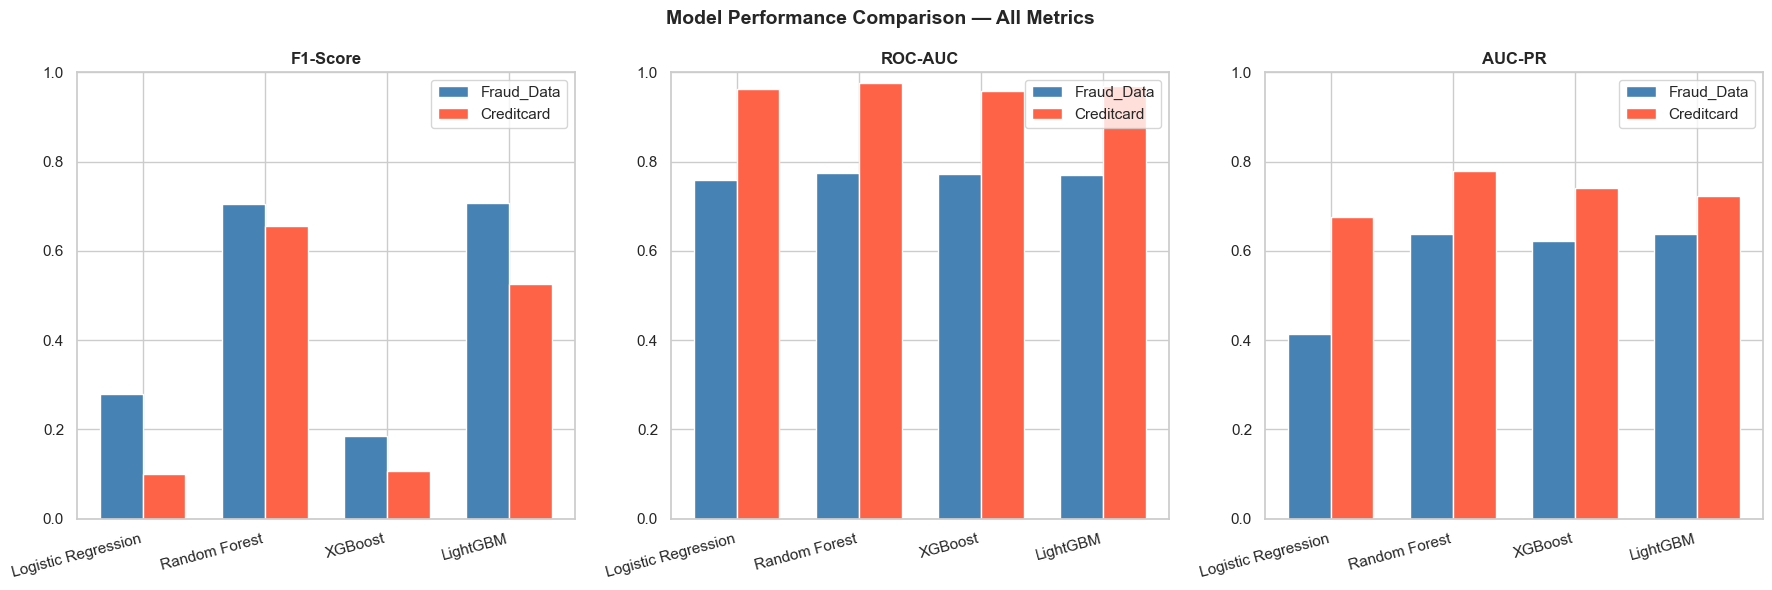

✅ Saved!


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics   = ['f1', 'roc_auc', 'auc_pr']
titles    = ['F1-Score', 'ROC-AUC', 'AUC-PR']
x         = np.arange(4)
width     = 0.35
model_names = [r['model_name'] for r in fraud_results]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    fraud_vals = [r[metric] for r in fraud_results]
    cc_vals    = [r[metric] for r in cc_results]

    axes[i].bar(x - width/2, fraud_vals, width,
                label='Fraud_Data', color='steelblue')
    axes[i].bar(x + width/2, cc_vals,    width,
                label='Creditcard',  color='tomato')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(model_names, rotation=15, ha='right')
    axes[i].set_ylim(0, 1)
    axes[i].legend()

plt.suptitle('Model Performance Comparison — All Metrics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_all.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [30]:
print("=" * 55)
print("       TASK 2 COMPLETE — SUMMARY")
print("=" * 55)

print("\n📊 MODELS TRAINED (each dataset):")
print("  ✅ Logistic Regression (baseline)")
print("  ✅ Random Forest")
print("  ✅ XGBoost")
print("  ✅ LightGBM")

print("\n📈 EVALUATION METRICS USED:")
print("  ✅ F1-Score")
print("  ✅ ROC-AUC")
print("  ✅ AUC-PR (primary — best for imbalanced data)")
print("  ✅ Confusion Matrix")

print("\n🔁 CROSS VALIDATION:")
print("  ✅ Stratified K-Fold (k=5) on Fraud_Data training set")

print(f"\n🏆 BEST MODEL (Fraud_Data):  {best_fraud['model_name']}")
print(f"   AUC-PR: {best_fraud['auc_pr']} | F1: {best_fraud['f1']}")

print(f"\n🏆 BEST MODEL (Creditcard):  {best_cc['model_name']}")
print(f"   AUC-PR: {best_cc['auc_pr']} | F1: {best_cc['f1']}")

print("\n💾 SAVED:")
print("  ✅ All model .pkl files in models/")
print("  ✅ All plots in data/processed/")

       TASK 2 COMPLETE — SUMMARY

📊 MODELS TRAINED (each dataset):
  ✅ Logistic Regression (baseline)
  ✅ Random Forest
  ✅ XGBoost
  ✅ LightGBM

📈 EVALUATION METRICS USED:
  ✅ F1-Score
  ✅ ROC-AUC
  ✅ AUC-PR (primary — best for imbalanced data)
  ✅ Confusion Matrix

🔁 CROSS VALIDATION:
  ✅ Stratified K-Fold (k=5) on Fraud_Data training set

🏆 BEST MODEL (Fraud_Data):  Random Forest
   AUC-PR: 0.638 | F1: 0.7061

🏆 BEST MODEL (Creditcard):  Random Forest
   AUC-PR: 0.7797 | F1: 0.6553

💾 SAVED:
  ✅ All model .pkl files in models/
  ✅ All plots in data/processed/
